<a href="https://colab.research.google.com/github/ML4SCI/DeepLearnHackathon/blob/main/GravitationalLensingChallenge/StrongLensingChallenge_SuperRes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task B: Image Super-Resolution

Gravitational lensing has been a cornerstone in many cosmology experiments and studies since it was discussed in Einstein’s calculations back in 1936 and discovered in 1979, and one area of particular interest is the study of dark matter via substructure in strong lensing images. In this challenge, we focus on exploring the potential of ML models in enhancing the resolution of lensing images.

In this task, we will develop and train a super-resolution model to enhance the quality of low-resolution strong gravitational lensing images. The goal is to upscale noisy and blurry images to higher resolutions, improving their clarity and detail. Participants can explore different super-resolution techniques, including convolutional neural networks (CNNs), generative adversarial networks (GANs), and other deep learning approaches.

![HR and LR Image Pair](https://github.com/pranath-reddy/DeepLearnHackathon/blob/main/GravitationalLensingChallenge/hr_lr_pair.png?raw=true)

This is an example notebook for the Image Super-Resolution Challenge. In this notebook, we demonstrate a simple CNN model implemented using the PyTorch library to solve the task of super-resolution of strong lensing images.

### Dataset

The Dataset consists of high-resolution (HR) and low-resolution (LR) pairs. The images have been normalized using min-max normalization.

Link to the Dataset: https://drive.google.com/file/d/1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld/view?usp=sharing

### Evaluation Metrics

* MSE (Mean Squared error), SSIM (Similarity Index), and PSNR (Signal to Noise Ratio)   

The model performance will be tested on the hidden test dataset based on the above metrics. More details about these metrics and the code to calculate them has been shared below.

### Instructions for using the notebook

1. Use GPU acceleration: (Edit --> Notebook settings --> Hardware accelerator --> GPU)
2. Run the cells: (Runtime --> Run all)

In [37]:
import os
import zipfile
import gdown

# Paths
drive_path = './drive/MyDrive/dataset_superres'
zip_path = './drive/MyDrive/dataset_superres.zip'
extract_path = './drive/MyDrive/'

# Google Drive file ID
file_id = "http://drive.google.com/uc?id=1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld"

# Create directories if needed
os.makedirs('./drive/MyDrive', exist_ok=True)

# Download the file if it doesn't exist
if not os.path.exists(drive_path):
    if not os.path.exists(zip_path):
        print("Downloading dataset...")
        gdown.download(url=file_id, output=zip_path, quiet=False)
        print("Download complete.")

    # Unzip the file
    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")

    # Rename the folder if needed
    default_folder = os.path.join(extract_path, 'dataset')
    if os.path.exists(default_folder):
        os.rename(default_folder, drive_path)
        print(f"Renamed folder to {drive_path}")

## Single Image Super Resolution

### 1. Data Visualization and Preprocessing

#### 1.1 Import all the necessary libraries

In [38]:
import numpy as np
import random
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torch.autograd import Variable
from tqdm.notebook import tqdm
import torch.utils.data as data
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from torch.optim.lr_scheduler import CosineAnnealingLR
%matplotlib inline

#### 1.2 Preview the Data

High-Resolution (HR) samples: 
-0.00019404306571709702
-6.949898725416343e-11
-0.00027226978939213185
-6.004804796810574e-11
-0.0036158705217916236


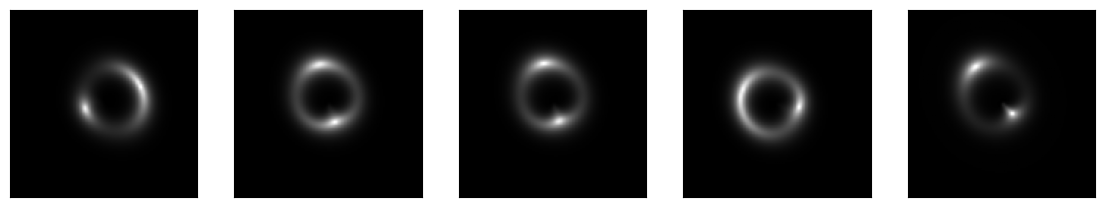

Low-Resolution (LR) samples: 


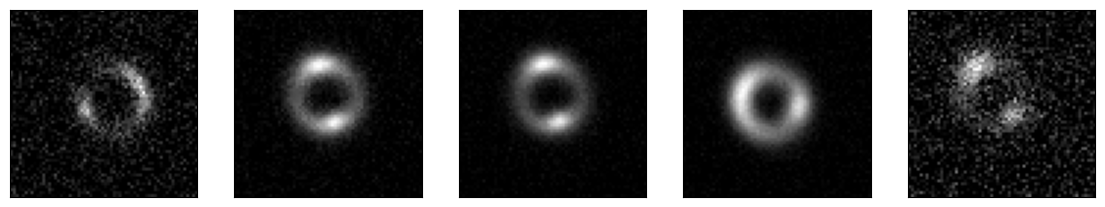

In [ ]:
# Define the input paths for high-resolution (HR) and low-resolution (LR) training images
train_hr_path = drive_path + '/train/HR'
train_hr_files = [os.path.join(train_hr_path, f) for f in os.listdir(train_hr_path) if f.endswith(".npy")]
train_lr_path = drive_path + '/train/LR'
train_lr_files = [os.path.join(train_lr_path, f) for f in os.listdir(train_lr_path) if f.endswith(".npy")]

# Number of samples to display
n = 5

# Plot the high-resolution (HR) samples
i = 1
print('High-Resolution (HR) samples: ')
plt.rcParams['figure.figsize'] = [14, 14]
for image in train_hr_files[:n]:  # Loop through the first n HR images
    ax = plt.subplot(2, n, i)  # Create subplot for the current image
    plt.imshow(np.load(image).reshape(128,128), cmap='gray')  # Load and display the image in grayscale
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1  # Increment the subplot index
plt.show()  # Display the plot

# Plot the low-resolution (LR) samples
print('Low-Resolution (LR) samples: ')
plt.rcParams['figure.figsize'] = [14, 14]
for image in train_lr_files[:n]:  # Loop through the first n LR images
    ax = plt.subplot(2, n, i)  # Create subplot for the current image
    plt.imshow(np.load(image).reshape(64,64), cmap='gray')  # Load and display the image in grayscale
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1  # Increment the subplot index
plt.show()  # Display the plot


#### 1.3 Import Training and Validation Data

In [ ]:
# Set Batch Size
batch_size = 32

# Define a custom Dataset class for loading Super Resolution data
class SuperResolutionDataset(data.Dataset):
    def __init__(self, lr_path, hr_path):
        # Initialize the dataset with lists of low-resolution and high-resolution image file paths
        self.lr_files = [os.path.join(lr_path, f) for f in os.listdir(lr_path) if f.endswith(".npy")]
        self.hr_files = [os.path.join(hr_path, f) for f in os.listdir(hr_path) if f.endswith(".npy")]

    def __len__(self):
        # Return the total number of low-resolution images (The number of HR and LR images is the same)
        return len(self.lr_files)

    def __getitem__(self, idx):
        # Load the low-resolution and high-resolution images from the file paths
        lr_image = np.load(self.lr_files[idx])
        hr_image = np.load(self.hr_files[idx])

        # Convert numpy arrays to PyTorch tensors and return them
        return torch.from_numpy(lr_image).float(), torch.from_numpy(hr_image).float()

# Create the training data loader
train_data = SuperResolutionDataset(drive_path+'/train/LR', drive_path+'/train/HR')
train_data_loader = data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)

# Create the validation data loader
val_data = SuperResolutionDataset(drive_path+'/val/LR', drive_path+'/val/HR')
val_data_loader = data.DataLoader(val_data, batch_size=batch_size, shuffle=True, num_workers=0)

### 2. Training

#### 2.1 Defining a Super-Resolution CNN Model

You may refer to this [article](https://medium.com/@RaghavPrabhu/understanding-of-convolutional-neural-network-cnn-deep-learning-99760835f148) to learn about Convolutional Neural Networks (CNN) and this [article](https://medium.com/coinmonks/review-srcnn-super-resolution-3cb3a4f67a7c) to learn more about how CNNs can be used for super-resolution.

In [42]:
# Define the Super-Resolution Convolutional Neural Network (SRCNN) model
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        # First convolutional layer: 1 input channel, 64 output channels, 9x9 kernel, 4 pixels padding
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=9, padding=4)
        # Second convolutional layer: 64 input channels, 32 output channels, 5x5 kernel, 2 pixels padding
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, padding=2)
        # Third convolutional layer: 32 input channels, 1 output channel, 5x5 kernel, 2 pixels padding
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=5, padding=2)
        # ReLU activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Apply the first convolutional layer followed by ReLU activation
        x = self.relu(self.conv1(x))
        # Apply the second convolutional layer followed by ReLU activation
        x = self.relu(self.conv2(x))
        # Apply the third convolutional layer
        x = self.conv3(x)
        # Upsample the output to the HR resolution using bicubic interpolation
        x = F.interpolate(x, size=(128, 128), mode='bicubic', align_corners=False)
        return x


In [43]:
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.ca = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, padding=0, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(channel // reduction, channel, 1, padding=0, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.ca(y)
        return x * y

class RCAB(nn.Module):
    def __init__(self, n_feat, kernel_size=3, reduction=16, bias=True):
        super(RCAB, self).__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat, kernel_size, padding=kernel_size//2, bias=bias),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feat, n_feat, kernel_size, padding=kernel_size//2, bias=bias),
            ChannelAttention(n_feat, reduction)
        )

    def forward(self, x):
        res = self.body(x)
        return res + x

class ResidualGroup(nn.Module):
    def __init__(self, n_feat, kernel_size, reduction, n_resblocks):
        super(ResidualGroup, self).__init__()
        modules_body = [RCAB(n_feat, kernel_size, reduction) for _ in range(n_resblocks)]
        modules_body.append(nn.Conv2d(n_feat, n_feat, kernel_size, padding=kernel_size//2))
        self.body = nn.Sequential(*modules_body)

    def forward(self, x):
        res = self.body(x)
        return res + x

class Upsampler(nn.Sequential):
    def __init__(self, scale, n_feat):
        m = []
        if scale in [2, 4, 8]:
            for _ in range(int(scale).bit_length() - 1):
                m.append(nn.Conv2d(n_feat, 4 * n_feat, 3, 1, 1))
                m.append(nn.PixelShuffle(2))
        elif scale == 3:
            m.append(nn.Conv2d(n_feat, 9 * n_feat, 3, 1, 1))
            m.append(nn.PixelShuffle(3))
        else:
            raise NotImplementedError
        super(Upsampler, self).__init__(*m)

class RCAN(nn.Module):
    def __init__(self, scale=2, n_resgroups=3, n_resblocks=6, n_feats=24, reduction=2, in_channels=1, out_channels=1):
        super(RCAN, self).__init__()

        kernel_size = 9

        # Head
        self.head = nn.Conv2d(in_channels, n_feats, kernel_size, padding=kernel_size//2)

        # Body
        self.body = nn.Sequential(
            *[ResidualGroup(n_feats, kernel_size, reduction, n_resblocks) for _ in range(n_resgroups)],
            nn.Conv2d(n_feats, n_feats, kernel_size, padding=kernel_size//2)
        )

        # Tail
        self.tail = nn.Sequential(
            Upsampler(scale, n_feats),
            nn.Conv2d(n_feats, out_channels, kernel_size, padding=kernel_size//2)
        )

    def forward(self, x):
        x = self.head(x)
        res = self.body(x)
        res += x
        x = self.tail(res)
        return x


#### 2.2 Training the Super-Resolution CNN Model

In [44]:
def train_model(model, device):
    # Loss Function
    alpha = 0.8
    beta = 0.2
    criteria = nn.MSELoss()  # Mean Squared Error Loss
    #l1_loss = nn.L1Loss().to(device)
    #ssm_metric = StructuralSimilarityIndexMeasure().to(device)
    #criteria = lambda y_out, y_tr: alpha * l1_loss(y_out,y_tr) + beta * (1 - ssm_metric(y_tr, y_out))

    # Optimizer (Adam)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=20)

    # Train the model
    n_epochs = 20  # Number of Training Epochs
    loss_array = []  # Array to store the loss values
    pbar = tqdm(range(1, n_epochs+1))  # Progress bar for tracking epochs
    for epoch in pbar:
        train_loss = 0.0  # Initialize training loss for the epoch

        # Iterate over the training data loader
        for step, (lr, hr) in enumerate(train_data_loader):

            lr = Variable(lr).type(torch.FloatTensor).to(device)  # Move low-resolution images to the device
            hr = Variable(hr).type(torch.FloatTensor).to(device)  # Move high-resolution images to the device
            optimizer.zero_grad()  # Clear the gradients
            outputs = model(lr)  # Forward pass through the model
            loss = criteria(outputs, hr)  # Calculate the loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the model parameters

            train_loss += loss.item()  # Accumulate the training loss

        train_loss = train_loss / len(train_data_loader)  # Compute average training loss for the epoch
        loss_array.append(train_loss)  # Append the loss to the loss array
        # Display the Training Stats
        pbar.set_postfix({'Training Loss': train_loss})  # Update progress bar with training loss
        scheduler.step()
        
    return model

In [45]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print("Training SRCNN Model")
srcnn_model = SRCNN().to(device)
srcnn_model = train_model(srcnn_model, device)

print("Training RCAN Model")
rcan_model = RCAN().to(device)
rcan_model = train_model(rcan_model, device)


cuda
Training SRCNN Model


  0%|          | 0/20 [00:00<?, ?it/s]

Training RCAN Model


  0%|          | 0/20 [00:00<?, ?it/s]

### 3. Testing

#### 3.1 Testing the Super-Resolution CNN Model on Validation Data - Calculate Quantitative Metrics

- **MSE (Mean Squared Error):** A measure of the average squared difference between the estimated values and the actual value. Lower values indicate better performance.

- **SSIM (Structural Similarity Index):** A method for measuring the similarity between two images. It is used to measure the quality of the super-resolved images compared to the original high-resolution images.

- **PSNR (Peak Signal-to-Noise Ratio):** The ratio between the maximum possible power of a signal and the power of corrupting noise that affects the fidelity of its representation. Higher values indicate better image quality.

You may refer to this [article](https://medium.com/@datamonsters/a-quick-overview-of-methods-to-measure-the-similarity-between-images-f907166694ee) to learn more about these metrics

*Note: Metrics need to be calculated on a sample-by-sample basis, not on a batch basis. This is because metrics like SSIM and PSNR are used for assessing the quality of individual images and the scikit-image functions do not average over the first axis when we pass batches of images to them.*

In [46]:
def calculate_metrics(dataSR, val_hr):
    losses = []  # List to store MSE losses
    losses2 = []  # List to store L1 losses
    Ssim = []  # List to store SSIM scores
    Psnr = []  # List to store PSNR scores
    mse_criteria = nn.MSELoss()  # Mean Squared Error Loss
    l1_criteria = nn.L1Loss()  # L1 Loss
    for i in range(dataSR.shape[0]):
        # Calculate MSE loss between predicted and ground truth images
        losses.append(mse_criteria(torch.from_numpy(dataSR[i]), torch.from_numpy(val_hr[i])))
        # Calculate L1 loss between predicted and ground truth images
        losses2.append(l1_criteria(torch.from_numpy(dataSR[i]), torch.from_numpy(val_hr[i])))
        # Calculate SSIM score between predicted and ground truth images
        Ssim.append(ssim(val_hr[i][0], dataSR[i][0], data_range=dataSR[i][0].max() - dataSR[i][0].min()))
        # Calculate PSNR score between predicted and ground truth images
        Psnr.append(psnr(val_hr[i][0], dataSR[i][0], data_range=dataSR[i][0].max() - dataSR[i][0].min()))

    return losses, losses2, Ssim, Psnr

In [ ]:
# Calculate Metrics

# Loss Function
alpha = 0.8
beta = 0.2
criteria = nn.MSELoss()  # Mean Squared Error Loss
l1_loss = nn.L1Loss().to(device)
ssm_metric = StructuralSimilarityIndexMeasure().to(device)
criteria = lambda y_out, y_tr: alpha * l1_loss(y_out,y_tr) + beta * (1 - ssm_metric(y_tr, y_out))

# Set the model to evaluation mode
rcan_model.eval()
srcnn_model.eval()
rcan_out = []  # List to store model predictions
srcnn_out = []
srcnn_val_loss = 0
rcan_val_loss = 0
N_val = 0

with torch.no_grad():  # Disable gradient calculation for validation
    for step, (lr, hr) in enumerate(val_data_loader):
        lr = lr.to(device)  # Move low-resolution images to the device
        hr = hr.to(device)  # Move high-resolution images to the device
        rcan_recon = rcan_model(lr)  # Get model predictions
        rcan_out.append(rcan_recon.cpu().detach().numpy())  # Append predictions to the list and move to CPU
        srcnn_recon = srcnn_model(lr)
        srcnn_out.append(srcnn_recon.cpu().detach().numpy())
        srcnn_val_loss += criteria(srcnn_recon,hr).cpu().detach().numpy()
        rcan_val_loss += criteria(rcan_recon, hr).cpu().detach().numpy()
        N_val = step
        del lr, hr, rcan_recon, srcnn_recon  # Free memory
        torch.cuda.empty_cache()  # Clear cached memory
    srcnn_val_loss /= (N_val+1)
    rcan_val_loss /= (N_val+1)
rcan_dataSR = np.concatenate(rcan_out, axis=0)  # Concatenate predictions along the batch axis
srcnn_dataSR = np.concatenate(srcnn_out, axis=0)  # Concatenate predictions along the batch axis

# Prepare ground truth for comparison
val_hr = []
for _, hr in val_data_loader:
    val_hr.append(hr.cpu().numpy())  # Append ground truth high-resolution images to the list and move to CPU
val_hr = np.concatenate(val_hr, axis=0)  # Concatenate ground truth images along the batch axis

# Calculate metrics
rcan_losses, rcan_losses2, rcan_ssim, rcan_psnr = calculate_metrics(rcan_dataSR, val_hr)
srcnn_losses,srcnn_losses2, srcnn_ssim, srcnn_psnr = calculate_metrics(srcnn_dataSR, val_hr)


# Print average metrics
print("SRCNN Metrics:")
print("Average MSE super resolution samples: " + str('%.7f' % np.average(srcnn_losses)))
print("Average L1 super resolution samples: " + str('%.7f' % np.average(srcnn_losses2)))
print("Average SSIM super resolution samples: " + str('%.5f' % np.average(srcnn_ssim)))
print("Average PSNR super resolution samples: " + str('%.5f' % np.average(srcnn_psnr)))
print("Average Loss: " + str('%.5f' % np.average(srcnn_val_loss)))
# Print average metrics
print("RCAN Metrics:")
print("Average MSE super resolution samples: " + str('%.7f' % np.average(rcan_losses)))
print("Average L1 super resolution samples: " + str('%.7f' % np.average(rcan_losses2)))
print("Average SSIM super resolution samples: " + str('%.5f' % np.average(rcan_ssim)))
print("Average PSNR super resolution samples: " + str('%.5f' % np.average(rcan_psnr)))
print("Average Loss: " + str('%.5f' % np.average(rcan_val_loss)))

SRCNN Metrics:
Average MSE super resolution samples: 0.0131737
Average L1 super resolution samples: 0.0403124
Average SSIM super resolution samples: 0.73834
Average PSNR super resolution samples: 19.01989
Average Loss: 0.00729
RCAN Metrics:
Average MSE super resolution samples: 0.0131969
Average L1 super resolution samples: 0.0401695
Average SSIM super resolution samples: 0.74721
Average PSNR super resolution samples: 19.17295
Average Loss: 0.00351


#### 3.2 Visualize Outputs for Qualitative Analysis

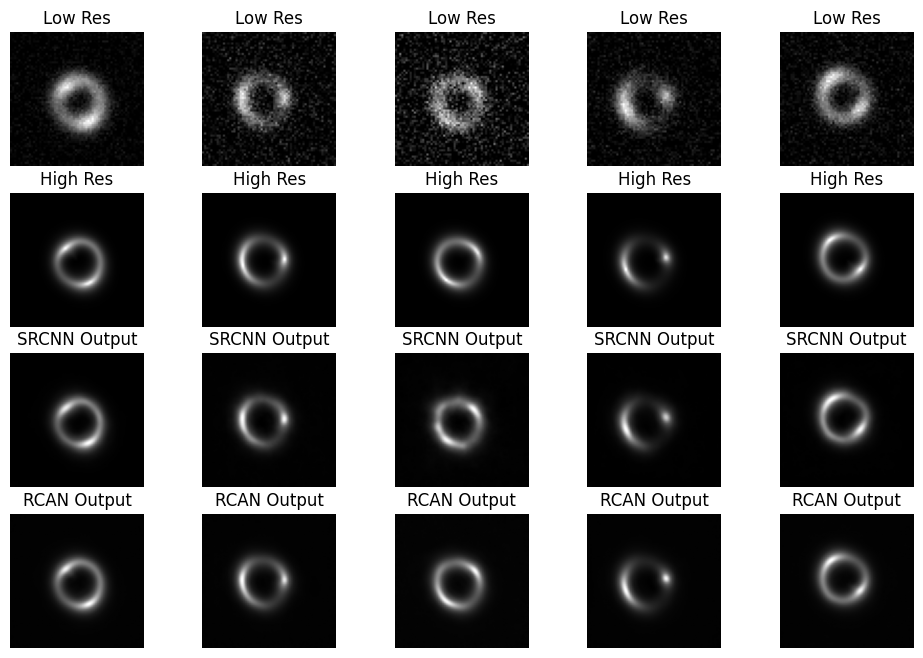

In [48]:
# Visualize Outputs
with torch.no_grad():  # Disable gradient calculation
    for lr, hr in val_data_loader:
        lr = lr.to(device)  # Move low-resolution images to the device
        hr = hr.to(device)  # Move high-resolution images to the device
        rcan_output = rcan_model(lr)  # Get model predictions
        srcnn_output = srcnn_model(lr)

        lr = lr.cpu().numpy()  # Move low-resolution images to CPU and convert to numpy array
        rcan_output = rcan_output.cpu().numpy()  # Move predicted images to CPU and convert to numpy array
        srcnn_output = srcnn_output.cpu().numpy()
        hr = hr.cpu().numpy()  # Move high-resolution images to CPU and convert to numpy array

        # Display the results
        plt.figure(figsize=(12, 8))  # Set figure size
        for i in range(5):  # Display first 5 images
            plt.subplot(4, 5, i + 1)  # Create subplot for low-resolution image
            plt.imshow(lr[i].reshape(64, 64), cmap='gray')  # Display low-resolution image in grayscale
            plt.title('Low Res')  # Set title for low-resolution image
            plt.axis('off')  # Hide axis
            plt.subplot(4, 5, i + 6)  # Create subplot for high-resolution image
            plt.imshow(hr[i].reshape(128, 128), cmap='gray')  # Display high-resolution image in grayscale
            plt.title('High Res')  # Set title for high-resolution image
            plt.axis('off')  # Hide axis
            plt.subplot(4, 5, i + 11)  # Create subplot for output image
            plt.imshow(srcnn_output[i].reshape(128, 128), cmap='gray')  # Display predicted image in grayscale
            plt.title('SRCNN Output')  # Set title for predicted image
            plt.axis('off')  # Hide axis
            plt.subplot(4, 5, i + 16)  # Create subplot for output image
            plt.imshow(rcan_output[i].reshape(128, 128), cmap='gray')  # Display predicted image in grayscale
            plt.title('RCAN Output')  # Set title for predicted image
            plt.axis('off')  # Hide axis
        plt.show()  # Display the figure
        break  # Break after first batch to visualize

## Submission Guidelines

* Fill out the pre- and post- hackathon surveys.
* You are required to submit a Google Colab Jupyter Notebook (.ipynb and pdf) clearly showing your implementation along with the evaluation metrics (MSE, SSIM, and PSNR) for the validation data.
* You must also submit the final trained model, including the model architecture and the trained weights ( For example: HDF5 file, .pb file, .pt file, etc. )
* You can use this example notebook as a template for your work.

> **_NOTE:_**  You are free to use any ML framework such as PyTorch, Keras, TensorFlow, etc.